### 0.Computer vision libs in pytorch:
torchvision.datasets->datasets
torchvision.models->transfer learning
torchvision.transforms->functions for manipulating your vision data
torch.utils.datya.Datset->Base dataset class for pytorch
torch.utils.data.DataLoaded->Creates python iterable over a dataset

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
torch.__version__,torchvision.__version__

('2.11.0+cu128', '0.26.0+cu128')

### 1.Getting a dataset:
The dataset we will be using is fashionmnist from torchvision.datasets:

In [2]:
#Setup training data:
from torchvision import datasets
train_data=datasets.FashionMNIST(root='data'#Where to download data to
                                 ,train=True #We want training version of dataset
                                 ,download=True,
                                 transform=torchvision.transforms.ToTensor() #Convert images to tensor ,
                                 ,target_transform=None #Dont transform labels
                                 )
#Setup testing data:
test_data=datasets.FashionMNIST(root='data',
                                train=False,
                                download=True,
                                transform=torchvision.transforms.ToTensor(),
                                target_transform=None)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]


In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
#See the first training example:
image,label=train_data[0]
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [5]:
class_names=train_data.classes #.classes is builtin for torchvision datasets
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### 1.1 Check input and output shapes of data:

In [7]:
#Check the shape of our image:
print(f"Image shape:{image.shape},label shape:{label}")
#1->color channel
#28->height
#28->width

Image shape:torch.Size([1, 28, 28]),label shape:9


For deep learning image representaion we have either:
NCHW:batchsize-color_channels-height-width
or NHCW:batch_size-height-width,color_channels

### 1.2 Visualizng our data:

Image shape:torch.Size([1, 28, 28])


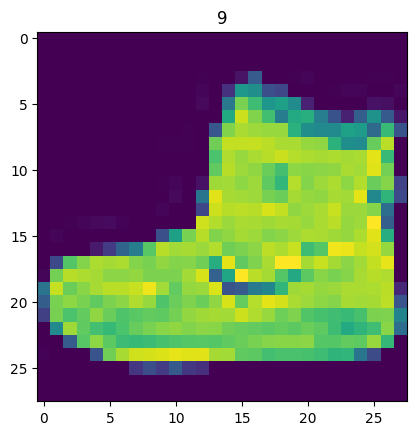

In [8]:
image,label=train_data[0]
print(f"Image shape:{image.shape}")
#matplotlpib expects color_channels last since we have them first we will squeeze to get rid of it
plt.imshow(image.squeeze())
plt.title(label)
plt.show()

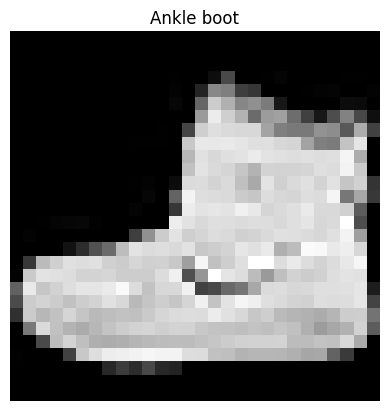

In [9]:
plt.imshow(image.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False)
plt.show()

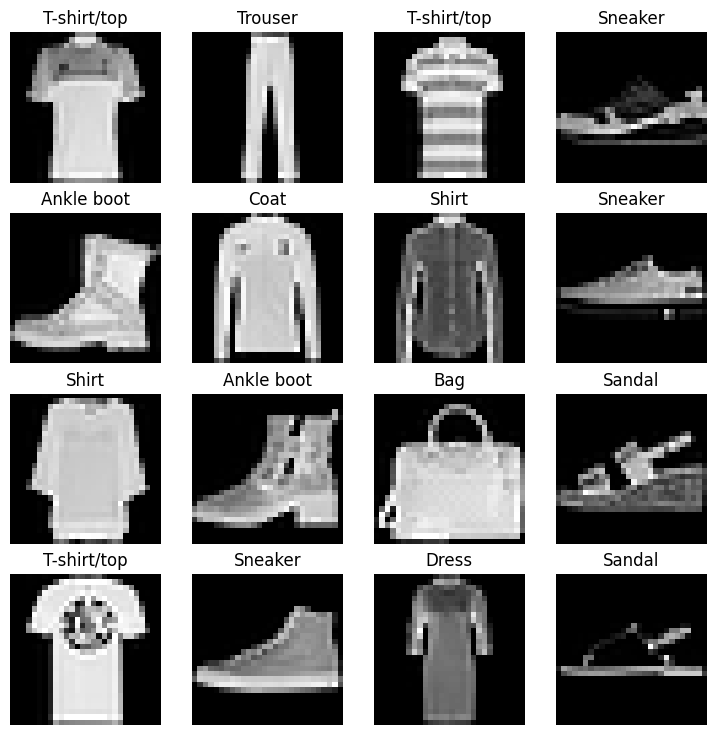

In [10]:
#Plot more images:
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  #size=[1]->get tensor with one value and dim
  #.item->makes the single values into an int
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap='grey')
  plt.axis(False)
  plt.title(class_names[label])


Will we need a model with non-linearity or not?

### 2. Prepare data-loader:
turns dataset into python iterable (batches/mini-batches)
we turn them into mini-batches since it is more computationaly friendly and gives model more chances to update its weights:

In [11]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [12]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader=DataLoader(dataset=train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bcb4a9c7b60>,
 <torch.utils.data.dataloader.DataLoader at 0x7bcb49ba16d0>)

In [13]:
print(f"DataLoaders:{train_dataloader,test_dataloader}")
print(f"Length of train_dataloader:{len(train_dataloader)}")
print(f"Length of test_dataloader:{len(test_dataloader)}")

DataLoaders:(<torch.utils.data.dataloader.DataLoader object at 0x7bcb4a9c7b60>, <torch.utils.data.dataloader.DataLoader object at 0x7bcb49ba16d0>)
Length of train_dataloader:1875
Length of test_dataloader:313


In [14]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
test_features_batch,test_labels_batch=next(iter(test_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size:torch.Size([1, 28, 28])
Label:0,label size:torch.Size([])


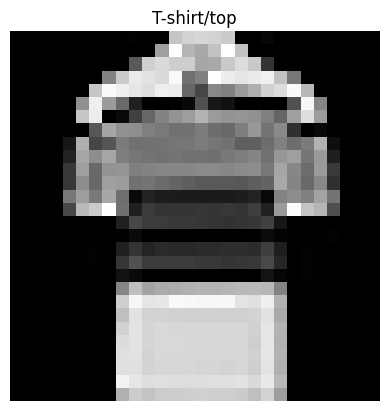

In [15]:
#Show a sample:
random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,label=train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image size:{img.shape}")
print(f"Label:{label},label size:{label.shape}")

### 3. Baseline model:

In [16]:
#Create a flatten_model
flatten_model=nn.Flatten()
x=train_features_batch[0]
output=flatten_model(x)
print(f"Before flattening:{x.shape},after flattening: {output.shape}")

Before flattening:torch.Size([1, 28, 28]),after flattening: torch.Size([1, 784])


In [17]:
#We use flatten cause our linear model cannot handle mutlidimensional data:
class modelv0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.layer_stack(x)

In [18]:
device='cuda' if torch.cuda.is_available() else 'cpu'
model_0=modelv0(input_shape=784,
                hidden_units=10,
                output_shape=10,
                )
model_0.to(device)

modelv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
device='cuda' if torch.cuda.is_available() else 'cpu'
dummy_x=torch.rand([1,1,28,28]).to(device)
model_0(dummy_x)

tensor([[-0.0616,  0.2695, -0.0486, -0.1245,  0.0676, -0.6009, -0.3010, -0.2432,
         -0.1757, -0.3220]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 3.1 Setup loss function and optmizer
loss->nn.CrossEntropyLoss()
optimizer->torch.optim.SGD
evaluation_metric->accuracy

In [20]:
import requests
from pathlib import Path
#Download helper functions from learn pytroch repo:
if Path('helper_functions.py').is_file():
  print("helper_functions.py already exists skipping download")
request=requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
with open('helper_functions.py','wb') as f:
  f.write(request.content)

In [21]:
#Import the accuracy metric:
from helper_functions import accuracy_fn
#Setup loss function and optimizer:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

### 3.3 Creating a function to time our experiments:

In [22]:
from timeit import default_timer as timer
def print_train_time(start:float,end:float,device:torch.device=None):
  total_time=end-start
  print(f"Train time on {device}:{total_time:.3f} seconds")
  return total_time

In [23]:
start_time=timer()
end_time=timer()
print_train_time(start=start_time,end=end_time,device='cpu')

Train time on cpu:0.000 seconds


4.882299981545657e-05

### 3.3 Creating a training loop and training model on batches of data :
1-Loop through epochs
2-Loop through training batches calculate train loss per batch
3-Loop through testsing batches calculate test loss per batch
4-Print out what's happening
5-Time it all (for fun)

In [24]:
#We will use this for our function:
str(next(model_0.parameters()).device)

'cuda:0'

In [25]:
from tqdm.auto import tqdm
torch.manual_seed(42)
model_0.to(device)
train_time_start_on_gpu=timer()
epochs=3
for epoch in tqdm(range(epochs)): #Wrap tqdm on iterator for it to work
  print(f"Epoch:{epoch}\n---")
  train_loss=0
  for batch ,(X,y) in enumerate(train_dataloader):
    X=X.to(device)
    y=y.to(device)
    model_0.train()
    y_pred=model_0(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
if batch % 400==0:
  print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")
  #Divide total train loss by lenght of train data loader:
train_loss/=len(train_dataloader)
### Testing:
test_loss,test_acc=0,0
model_0.eval()
with torch.inference_mode():
  for X_test,y_test in test_dataloader:
    #1 Forward pass:
    X_test=X_test.to(device)
    y_test=y_test.to(device)
    test_pred=model_0(X_test)
    #2 Calculate loss(accumulatively)
    test_loss+=loss_fn(test_pred,y_test)
    #3 calculate accuracy:
    test_acc+=accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
  #Calculate the test loss average per batch:
  test_loss/=len(test_dataloader)
  #Calculate the test acc average per batch:
  test_acc/=len(test_dataloader)
#Print out what is happening:
print(f"/n Train loss:{train_loss:.4f}|Test loss:{test_loss:.4f},Test acc:{test_acc:.4f}")
#Calculate training time:
train_time_end_on_gpu=timer()
total_train_time_model_0=print_train_time(start=train_time_start_on_gpu,
                                          end=train_time_end_on_gpu,
                                          device=str(next(model_0.parameters()).device))




  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
---
Epoch:1
---
Epoch:2
---
/n Train loss:0.4548|Test loss:0.5157,Test acc:82.1286
Train time on cuda:0:27.062 seconds


In [26]:
device

'cuda'

### 4 Make predictions and get model 0 results:

In [27]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn):
  """
  Returns a dictionnary containing the results of model predicting on data_loader.
  """
  loss,acc=0.0,0.0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      X=X.to(device)
      y=y.to(device)
      #Make predictions:
      y_pred=model(X)
      #Accumulate the loss and acc values per batch:
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    #Scale loss and acc to find average loss/acc per batch:
    loss/=len(data_loader)
    acc/=len(data_loader)
  return {'model_name':model.__class__.__name__#Only works when model was created with a class
          ,'model_loss':loss
          ,'model_acc':acc}

In [28]:
model_0_results=eval_model(model=model_0,
                        data_loader=test_dataloader,
                        loss_fn=loss_fn,
                        accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'modelv0',
 'model_loss': tensor(0.5153, device='cuda:0'),
 'model_acc': 82.11861022364218}

In [29]:
torch.cuda.is_available()

True

In [30]:
!nvidia-smi

Sun Sep 13 13:18:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             28W /   70W |     161MiB /  15360MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 5 Setup device agnostic code:

In [31]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [32]:
class modelv1(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layerstack=nn.Sequential(
        nn.Flatten()
        ,nn.Linear(in_features=input_shape,out_features=hidden_units)
        ,nn.ReLU()
        ,nn.Linear(in_features=hidden_units,out_features=hidden_units)
        ,nn.ReLU()
        )
  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.layerstack(x)

In [33]:
#Create an insatnce of model 1:
torch.manual_seed(42)
model_1=modelv1(input_shape=784,
                hidden_units=10,
                output_shape=10).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss ,optimizer and evaluation metrics:

In [34]:
from helper_functions import accuracy_fn
#Creating loss function and optimizer for model_1
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

### 6.2 Functionizing training and evaluation/testing loops:
training_loop->train_step()
testing_loop->testing_step()

In [35]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               optimizer:torch.optim,
               device:torch.device=device):
  '''
  Performs training step on model training to learn on data loader:
  '''
  train_loss,train_acc=0,0
  model.train()
  for batch ,(X,y) in enumerate(data_loader):
      X,y=X.to(device),y.to(device)
      #1 Forward pass outputs the raw logits of the model:
      y_pred=model(X)
      #2.Calculate loss and accuracy per batch:
      loss=loss_fn(y_pred,y)
      train_loss+=loss
      train_acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
  if batch % 400==0:
      print(f"Looked at {batch*len(X)}/{len(data_loader.dataset)} samples")
  #Divide total train loss by lenght of train data loader:
  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"Train loss:{train_loss:.4f},Train acc:{train_acc:.2f}")

In [36]:
def test_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):
  '''
  Performs testing step on model training to learn on data loader:
  '''
  #Put model in eval mode:
  test_loss,test_acc=0,0
  model.eval()
  #Turn on context manager:
  with torch.inference_mode():
      for batch ,(X,y) in enumerate(data_loader):
          X,y=X.to(device),y.to(device)
          #1 Forward pass outputs the raw logits of the model:
          y_pred=model(X)
          #2.Calculate loss and accuracy per batch:
          loss=loss_fn(y_pred,y)
          test_loss+=loss
          test_acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
  if batch % 400==0:
      print(f"Looked at {batch*len(X)}/{len(data_loader.dataset)} samples")
  #Divide total train loss by lenght of train data loader:
  test_loss/=len(data_loader)
  test_acc/=len(data_loader)
  print(f"Test loss:{test_loss:.5f},Test acc:{test_acc:.2f}")

In [37]:
from timeit import default_timer as timer
train_time_start=timer()
torch.manual_seed(42)
epochs=3
for epoch in tqdm(range(epochs)):
  print(f"Epoch:{epoch}\n")
  train_step(model=model_1,data_loader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,accuracy_fn=accuracy_fn,device=device)
train_time_end=timer()
train_time=print_train_time(start=train_time_end ,end=train_time_start,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0

Train loss:1.0920,Train acc:61.34
Epoch:1

Train loss:0.7687,Train acc:72.45
Epoch:2

Train loss:0.6665,Train acc:76.09
Train time on cuda:-27.051 seconds


Note:Smetimes depending on data/hardware model may train faster on cpu/gpu
1-overhead from cpu to gpu outweights benefits from gpu to cpu:
2-Hardware using might have better compute than gpu (which is rare)

In [38]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device=device):
  """
  Returns a dictionnary containing the results of model predicting on data_loader.
  """
  loss,acc=0.0,0.0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      X=X.to(device)
      y=y.to(device)
      #Make predictions:
      y_pred=model(X)
      #Accumulate the loss and acc values per batch:
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    #Scale loss and acc to find average loss/acc per batch:
    loss/=len(data_loader)
    acc/=len(data_loader)
  return {'model_name':model.__class__.__name__#Only works when model was created with a class
          ,'model_loss':loss
          ,'model_acc':acc}

In [39]:
#Get model_1 results dictionnary:
model_1_results=eval_model(model=model_1,
    data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                           device=device)

  0%|          | 0/313 [00:00<?, ?it/s]

In [40]:
model_1_results

{'model_name': 'modelv1',
 'model_loss': tensor(0.6896, device='cuda:0'),
 'model_acc': 74.97004792332268}

In [41]:
model_0_results

{'model_name': 'modelv0',
 'model_loss': tensor(0.5153, device='cuda:0'),
 'model_acc': 82.11861022364218}

### Model 2 :Building a convolutional neural-network:

In [44]:
import torch
import torch.nn as nn

class Model2(nn.Module):
    """
    Replication of the TinyVGG model architecture from CNN Explainer.
    Assumes an input image size of 64x64 (spatial dimensions downsampled to 16x16).
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # 64x64 image -> 32x32 (after block 1) -> 16x16 (after block 2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units *0, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block2(x)
        print(x.shape)
        x = self.classifier(x)
        return x

In [43]:
torch.manual_seed(42)
model_2=Model2(input_shape=1,hidden_units=10,output_shape=len(class_names)).to(device)
model_2


Model2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=10, bias=True)
  )
)

### 7.1 Stepping through (nn.conv2d):

In [54]:
torch.manual_seed(42)
#Create a batch of images:
images=torch.randn(32,3,64,64)
test_image=images[0]
print(f"Image batch shape:{images.shape}")
print(f"Single image shape:{test_image.shape}")

Image batch shape:torch.Size([32, 3, 64, 64])
Single image shape:torch.Size([3, 64, 64])


In [60]:
#Create a single conv2d layer
conv_layer=nn.Conv2d(in_channels=3,
                     out_channels=10,
                     kernel_size=3,
                     stride=1,
                     padding=0)
#Pass the data through the convolutional layer:
conv_output=conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 62, 62])

In [57]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])